In [1]:
import numpy as np, tools_cmb, pickle, curvedsky as cs, healpy as hp, local, cmb
from matplotlib.pyplot import *

In [2]:
import importlib
importlib.reload(tools_cmb)

<module 'tools_cmb' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_cmb.py'>

In [3]:
def cli(cl):
    ret = np.zeros_like(cl)
    ret[np.where(cl > 0)] = 1. / cl[np.where(cl > 0)]
    return ret

In [4]:
lmax = 1024
lonra, latra = [-80,80], [-70,-30]
nside = 512
npix = 12*nside**2
root = '/global/cscratch1/sd/lonappan/S4BIRD/DELL_noisefix/s1d1/'
pobj = local.analysis()

In [5]:
bl = cmb.beam(15.,lmax,inv=False)

In [6]:
fl = np.ones(lmax+1)
fl[:20] = 0.

In [7]:
nl = pickle.load(open(root+'/noise_mean_500.pkl',"rb"))
nEE = nl[1]/cmb.Tcmb**2
nBB = nl[2]/cmb.Tcmb**2

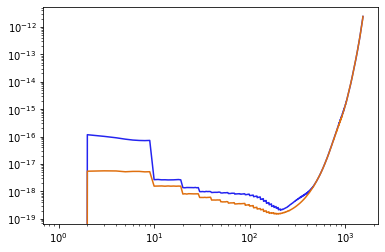

In [8]:
loglog(nEE)
loglog(nBB)

In [9]:
wElm, wBlm = pickle.load(open(root+'/Filtered/cinv_EB_0000_fsky_0p80.pkl',"rb"))

In [10]:
wEE = cs.utils.alm2cl(lmax,wElm[:lmax+1,:lmax+1])
wBB = cs.utils.alm2cl(lmax,wBlm[:lmax+1,:lmax+1])

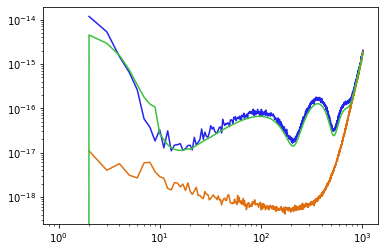

In [11]:
loglog(1./wEE)
loglog(1./wBB)
loglog(pobj.lcl[1,:lmax+1]+nEE[:lmax+1])

In [12]:
wEmap = cs.utils.hp_alm2map(nside,lmax,lmax,wElm[:lmax+1,:lmax+1])

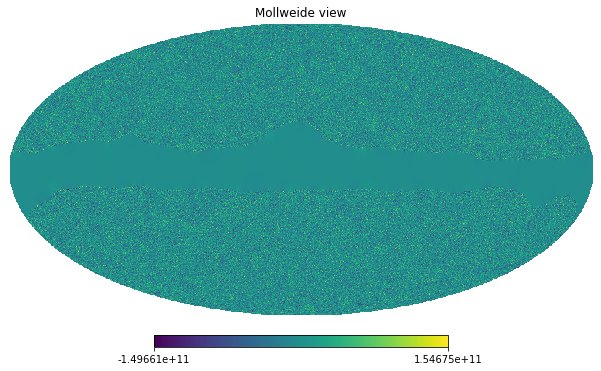

In [13]:
hp.mollview(wEmap)

In [14]:
hElm, hBlm = hp.read_alm(root+'/Maps/sims_0001.fits',(2,3))

In [15]:
cElm = hp.almxfl(hElm,bl,inplace=True)/cmb.Tcmb
cBlm = hp.almxfl(hBlm,bl,inplace=True)/cmb.Tcmb

In [16]:
TQU = hp.alm2map([cElm*0.,cElm,cBlm],nside=nside)

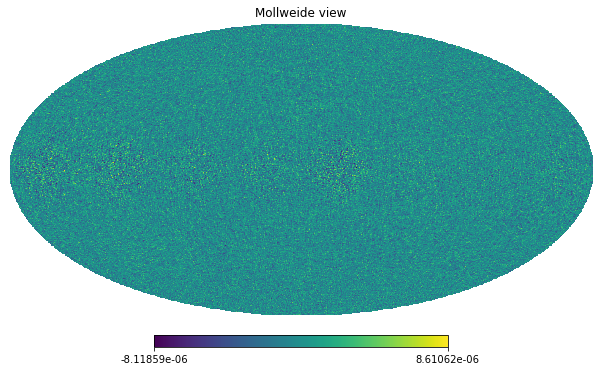

In [17]:
hp.mollview(TQU[1])

In [18]:
Elm, Blm = cs.utils.hp_map2alm_spin(nside,lmax,lmax,2,TQU[1],TQU[2])

In [19]:
EE = cs.utils.alm2cl(lmax,Elm)
BB = cs.utils.alm2cl(lmax,Blm)

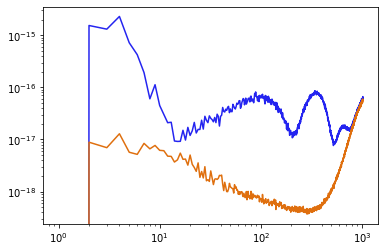

In [20]:
loglog(EE)
loglog(BB)

In [21]:
#mask = tools_cmb.prepare_masks(nside)['lbfull']
mask = hp.ud_grade(hp.read_map('../data/lensing/Masks/LB_Nside2048_fsky_0p8_binary.fits'),nside)
fsky = np.average(mask)

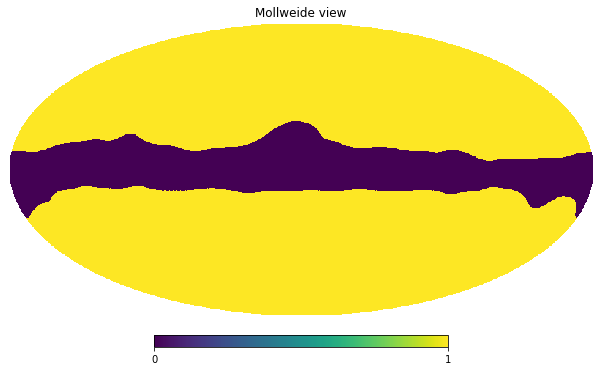

In [22]:
hp.mollview(mask)

In [23]:
data = np.reshape( np.array( (TQU[1]*mask, TQU[2]*mask) ), (2,1,npix) )

In [24]:
invN = np.reshape( np.array( (mask, mask) ), (2,1,npix) )

In [25]:
iNls = np.reshape( np.array( ( cli(nEE[:lmax+1]*bl**2), cli(nBB[:lmax+1]*bl**2) ) ), (2,1,lmax+1) )

In [26]:
Bl = np.reshape(bl,(1,lmax+1))

In [27]:
welm, wblm = cs.cninv.cnfilter_freq(2,1,nside,lmax,pobj.lcl[1:3,:lmax+1],Bl,invN,data,inl=iNls,chn=1,itns=[1000],eps=[1e-4],ro=10,stat='stat.txt',filter='')

In [28]:
wemap = cs.utils.hp_alm2map(nside,lmax,lmax,welm[:lmax+1,:lmax+1])

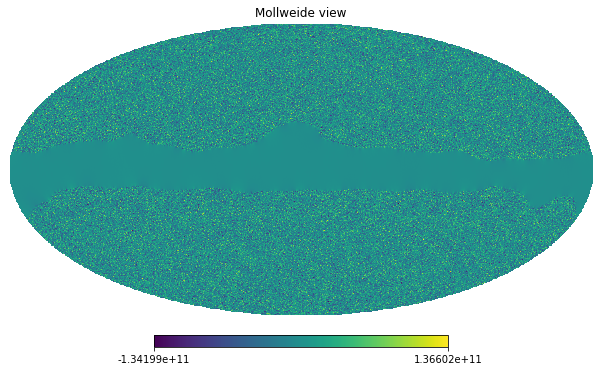

In [29]:
hp.mollview(wemap)

In [30]:
wee = cs.utils.alm2cl(lmax,welm)
wbb = cs.utils.alm2cl(lmax,wblm)

In [31]:
Q, U = hp.read_map(pobj.ficmb[2],field=(1,2))/cmb.Tcmb
Elm, Blm = cs.utils.hp_map2alm_spin(hp.get_nside(Q),lmax,lmax,2,Q,U)

In [32]:
iEE = cs.utils.alm2cl(lmax,Elm)
iBB = cs.utils.alm2cl(lmax,Blm)
xee = cs.utils.alm2cl(lmax,welm,Elm)
xbb = cs.utils.alm2cl(lmax,wblm,Blm)

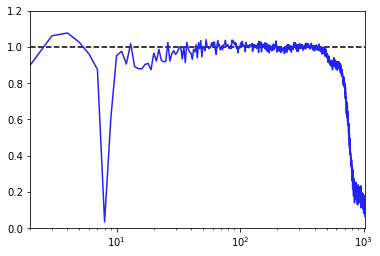

In [36]:
xscale('log')
axhline(1,color='k',ls='--')
xlim(2,lmax)
ylim(0,1.2)
plot(np.sqrt(xee**2/wee/iEE/fsky))

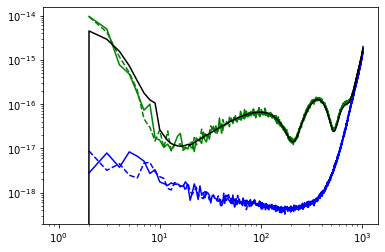

In [34]:
loglog(1./(wee/fsky),color='g',ls='-')
loglog(1./(wbb/fsky),color='b',ls='-')
loglog(1./(wEE/fsky),color='g',ls='--')
loglog(1./(wBB/fsky),color='b',ls='--')
loglog(pobj.lcl[1,:lmax+1]+nEE[:lmax+1],color='k')